# Test for mesh

This notebook is just to make sure everything is in line with a short example

In [ ]:
import jax.numpy as jnp
import sys
import os
sys.path.append('../..')  
from jax_fvm.src.mesh.mesh import Mesh 

import numpy as np
import matplotlib.pyplot as plt
import meshpy.triangle as triangle
from matplotlib import tri as mtri


size = 4
params = {
    'text.usetex': True,
    'font.family': 'serif',
    'font.serif': 'cm',  # Computer Modern font
	'legend.fontsize':size,
    'axes.labelsize' : size,
	'axes.titlesize' : size +2,
    'xtick.labelsize' : size+1,
    'ytick.labelsize' : size+1
}
plt.rcParams.update(params)


In [ ]:
# mesh = Mesh()
# mesh.mesh_generator(maxV=5e-4) # with periodic BC by default


mesh = Mesh()
L = 1
h = 1e-2

# N_maille = 4 * int(np.floor(np.sqrt(1/h)))
# boundaries = np.array([[x, -L] for x in np.linspace(-L,L,N_maille)][:-1])
# markers  = [1] * (N_maille - 1)
# boundaries = np.concatenate([boundaries, np.array([[L, y] for y in np.linspace(-L,L,N_maille)][:-1])])
# markers.extend([1] * (N_maille - 1))
# boundaries = np.concatenate([boundaries, np.array([[x, L] for x in np.linspace(L,-L,N_maille)][:-1])])
# markers.extend([1] * (N_maille - 1))
# boundaries = np.concatenate([boundaries, np.array([[ -L, y] for y in np.linspace(L,-L,N_maille)][:-1])])
# markers.extend([1] * (N_maille-1))

# info = triangle.MeshInfo()
# info.set_points(boundaries)
# info.set_facets(mesh.round_trip_connect(0, len(boundaries)-1), facet_markers=markers)

# mesh.mesh_generator(info = info, maxV=h)

mesh.mesh_generator(maxV = 2e-3, marker_boundary=1)

In [ ]:
mesh.neighbors[1]
print("barycenter of triangle 1: ")
print(mesh.barycenter[1])
print("barycenter of the neighbor of triangle 1: ")
print(mesh.barycenter[mesh.neighbors[1]])

barycenter of triangle 1: 
[0.01587302 0.01587302]
barycenter of the neighbor of triangle 1: 
[[0.9861111  0.02976191]
 [0.01587302 0.984127  ]
 [0.03968254 0.03515676]]


In [ ]:
list_tris_boundary = jnp.where(jnp.max(mesh.face_markers[mesh.face_connectivity] == 1, axis = -1))[0]
list_tris_boundary

Array([  1,   4,   5,   7,  12,  13,  14,  16,  23,  25,  26,  28,  29,
        30,  31,  35,  36,  37,  41,  42,  43,  46,  47,  49,  51,  55,
        58,  59,  61,  63,  64,  65,  67,  71,  73,  80,  84,  85,  89,
        92,  95,  99, 100, 102, 103, 111, 117, 118, 119, 121, 123, 125,
       126, 131, 133, 137, 144, 145, 147, 148, 149, 152, 155, 157, 160,
       168, 176, 178, 184, 186, 188, 194, 200, 207, 214, 224, 227, 228,
       242, 268, 662, 664], dtype=int32)

100
59
3


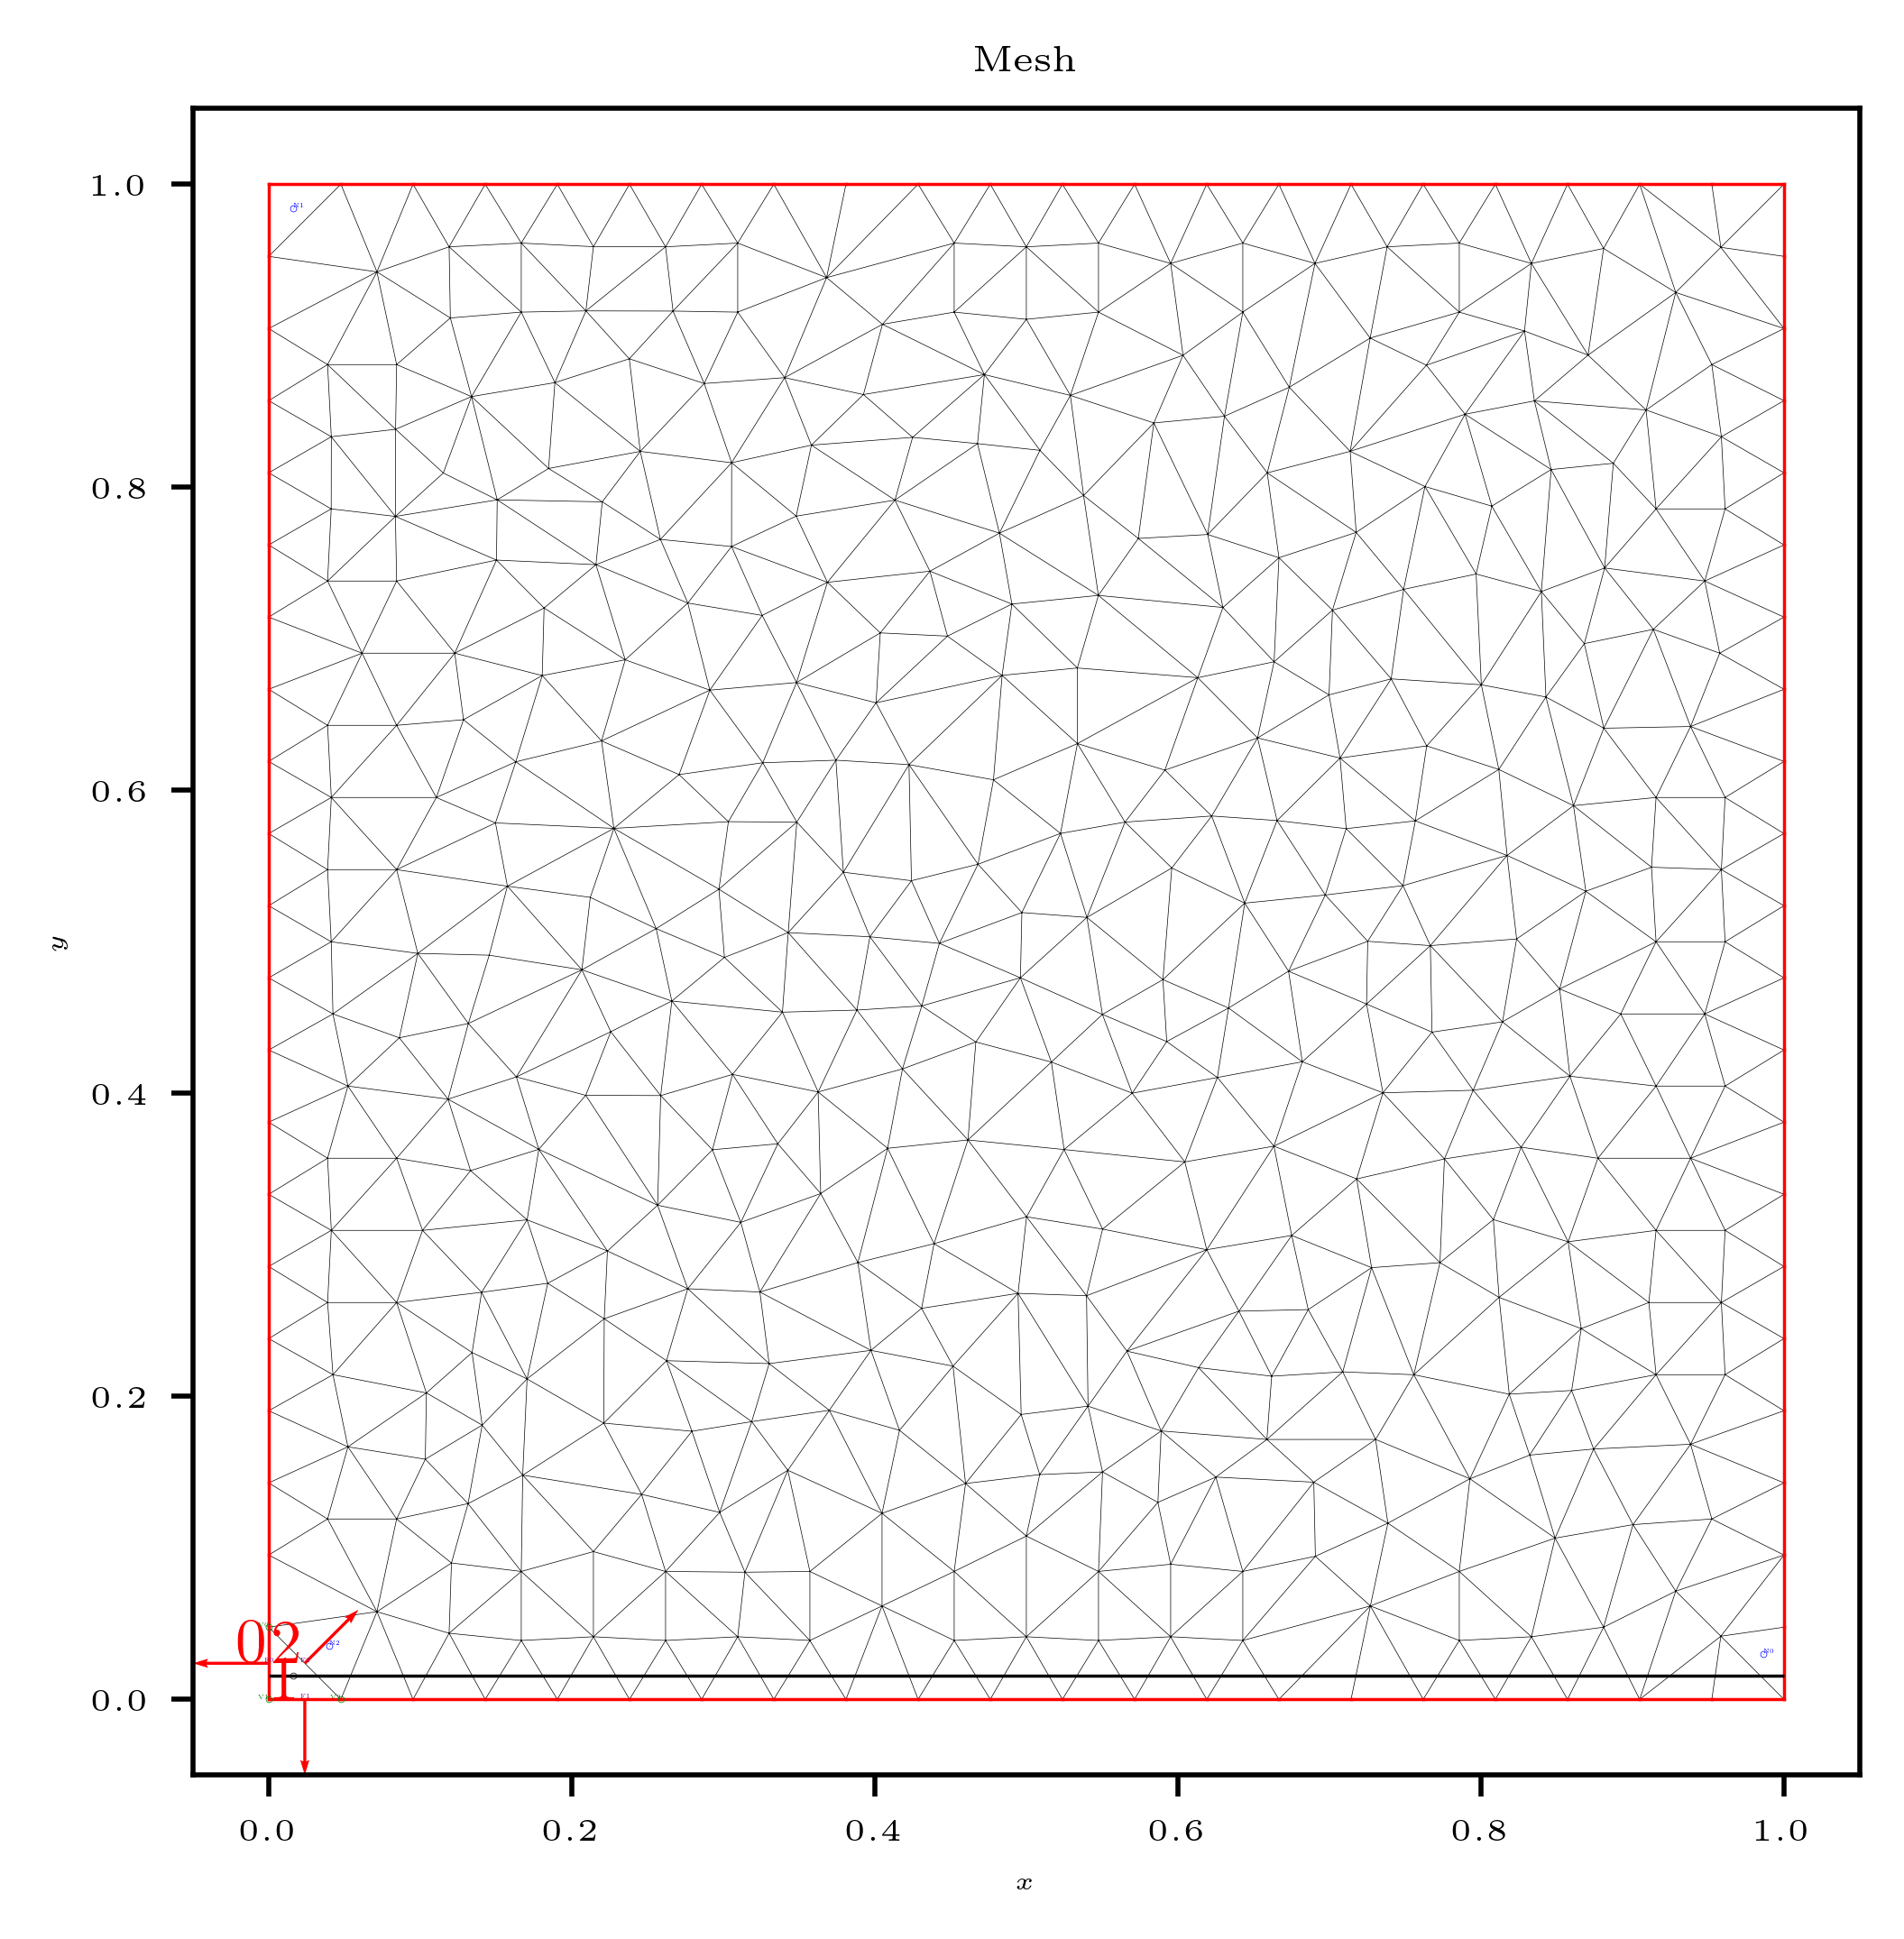

In [ ]:
triang = mtri.Triangulation(mesh.points[:, 0], mesh.points[:, 1], mesh.tris)

fig, ax = plt.subplots(dpi = 500)
ax.triplot(triang, color='black', lw=0.1)
for bc_marker in jnp.nonzero(jnp.unique(mesh.face_markers))[0]:
    ids = jnp.where(mesh.face_markers == bc_marker)[0]
    for id in ids:
        ax.plot(mesh.points[mesh.faces[id]][...,0], mesh.points[mesh.faces[id]][...,1], 
                color='red', lw=0.5)
ax.set_aspect('equal')
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$y$')
ax.set_title('Mesh')

# Get one triangle 
tri = 1

# plot barycenter
ax.plot(mesh.barycenter[tri,0], mesh.barycenter[tri,1], 'o', color='black', markersize=0.1)

# plot normals
for i in range(3):
    mid  = 0.5 * (mesh.points[mesh.tris[tri,(i)%3]] + mesh.points[mesh.tris[tri,(i+1)%3]])
    ax.quiver(mid[0], mid[1],
             mesh.normals[tri,i,0], mesh.normals[tri,i,1],label = str(i),
            color = 'r', scale=20, width=0.002, units='xy', angles='xy')
    ax.text(*mid.T, str(i),
            ha="right", color='red', size=10.)
    
# plot neighbors
for i in range(3):
    neighbor = mesh.neighbors[tri,i]
    print(neighbor)
    if neighbor != -1:
        plt.plot(mesh.barycenter[neighbor,0], mesh.barycenter[neighbor,1], 'o', color='blue', markersize=0.1)
        ax.text(mesh.barycenter[neighbor,0], mesh.barycenter[neighbor,1], f'N{i}',
                ha="left", color='blue', size=0.3)
        
# plot triangle vertices
for i in range(3):
    vertex = mesh.tris[tri,i]
    plt.plot(mesh.points[vertex,0], mesh.points[vertex,1], 'o', color='green', markersize=0.1)
    ax.text(mesh.points[vertex,0], mesh.points[vertex,1], f'V{i}',
            ha="right", color='green', size=0.3)
    
# plot face adjacency
for i in range(3):
    face = mesh.face_connectivity[tri,i]
    mid  = 0.5 * (mesh.points[mesh.tris[tri,(i)%3]] + mesh.points[mesh.tris[tri,(i+1)%3]])
    ax.text(mid[0], mid[1], f'F{i}',
            ha="center", va="bottom", color='purple', size=0.3)

ax.hlines(mesh.barycenter[tri,1], 0, L, color='black', lw=0.5)


In [ ]:
mesh.neighbors[1]

Array([100,  59,   3], dtype=int32)